# Drone-versus-bird radar classification baseline

This notebook audits an extracted `Data` directory, converts each recording into a documented micro-Doppler representation, trains a leakage-checked logistic classifier, evaluates it on held-out recording groups, and exports a reproducible model bundle. It follows `AI_2.md` and checks the active capture implementation in `rawdatacapture/Design guide.md` and `rawdatacapture/profile.cfg`.

**Scope:** the archive contains DJI Mavic and Phantom 3 Pro drones, bionic birds, and one pole recording. Consequently, this is an **archive drone-vs-bionic-bird baseline**, not a validated general drone detector. The pole is excluded from binary training and retained as an unknown robustness probe. Deployment requires held-out IWR6843ISK-ODS recordings.

**Input contract:** each example is `micro_doppler[2, 48, 64]`, where channel 0 is target-gate `log1p` power and channel 1 is target-to-neighbouring-range-background log contrast. The 48 steps correspond to about 1.60 s in the active 30 Hz live setup. Archive timing metadata is absent, so 48 archive frames must not be claimed to represent the same physical duration.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
from __future__ import annotations

import ctypes
import gc
import hashlib
import io
import json
import os
import pickle
import platform
import re
import shutil
import sys
import time
import warnings
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy import fft as sp_fft
from sklearn import __version__ as sklearn_version
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, brier_score_loss,
    confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

RANDOM_STATE = 42
WINDOW_STEPS = 48
DOPPLER_BINS = 64
WINDOW_STRIDE = 24  # overlap is allowed only within a recording group
FEATURE_VERSION = "archive-micro-doppler-v3"
PIPELINE_REVISION = "adaptive-core-extraction-r7"
MAX_RECORDINGS = None  # set an integer only for a quick smoke test
CACHE_FEATURES = True
DRIVE_DOWNLOAD_WORKERS = 8
DRIVE_STREAM_CHUNK_MIB = 8
DRIVE_DOWNLOAD_RETRIES = 5

def detect_available_cpu_cores() -> int:
    # os.cpu_count() can expose host CPUs that a Colab container cannot use.
    try:
        affinity_cores = len(os.sched_getaffinity(0))
    except (AttributeError, OSError):
        affinity_cores = os.cpu_count() or 1

    quota_cores = None
    try:
        quota, period = Path("/sys/fs/cgroup/cpu.max").read_text().strip().split()
        if quota != "max":
            quota_cores = max(1, int(quota) // int(period))
    except (OSError, ValueError):
        try:
            quota = int(Path("/sys/fs/cgroup/cpu/cpu.cfs_quota_us").read_text())
            period = int(Path("/sys/fs/cgroup/cpu/cpu.cfs_period_us").read_text())
            if quota > 0:
                quota_cores = max(1, quota // period)
        except (OSError, ValueError):
            pass

    return max(1, min(affinity_cores, quota_cores) if quota_cores else affinity_cores)

AVAILABLE_CPU_CORES = detect_available_cpu_cores()
FEATURE_EXTRACTION_WORKERS = AVAILABLE_CPU_CORES

IS_COLAB = "google.colab" in sys.modules
DRIVE_API = None
DRIVE_CREDENTIALS = None
if IS_COLAB:
    from google.colab import auth, drive
    from google.auth import default as google_auth_default
    from google.auth.exceptions import TransportError
    from google.auth.transport.requests import AuthorizedSession
    from googleapiclient.discovery import build
    from requests import RequestException
    drive_root = Path("/content/drive/MyDrive")
    try:
        drive_is_healthy = drive_root.is_dir() and next(drive_root.iterdir(), None) is not None
    except OSError:
        drive_is_healthy = False
    if not drive_is_healthy:
        print("Google Drive mount is unavailable or stale; remounting it.")
        drive.mount("/content/drive", force_remount=True)
    auth.authenticate_user()
    DRIVE_CREDENTIALS, _ = google_auth_default()
    DRIVE_API = build("drive", "v3", credentials=DRIVE_CREDENTIALS, cache_discovery=False)

configured_repo = os.environ.get("RADAR_UREX_REPO")
repo_candidates = ([Path(configured_repo)] if configured_repo else []) + [
    Path.cwd(), Path("/content/Radar-UREx"), Path("/content/drive/MyDrive/UREX/Radar-UREx")
]
REPO = next((path for path in repo_candidates if (path / "AI_2.md").exists()), None)
if REPO is None:
    raise RuntimeError("Radar-UREx repository not found. Set RADAR_UREX_REPO or run from its root.")
REPO = REPO.resolve()
os.chdir(REPO)

configured_source = os.environ.get("RADAR_UREX_DATA_SOURCE")
default_source = Path("/content/drive/MyDrive/Data") if IS_COLAB else Path(r"C:\Users\eliwe\Desktop\UREX\Data")
DATA_SOURCE = Path(configured_source) if configured_source else default_source
if IS_COLAB:
    drive_output = Path("/content/drive/MyDrive/UREX/Radar-UREx-output")
    CACHE_PATH = drive_output / "classification_features_v3.npz"
    ARTIFACT_DIR = drive_output / "artifacts"
else:
    CACHE_PATH = REPO / "tmp" / "classification_features_v3.npz"
    ARTIFACT_DIR = REPO / "artifacts"

print({
    "python": platform.python_version(), "numpy": np.__version__,
    "scipy": scipy.__version__, "scikit_learn": sklearn_version,
    "pipeline_revision": PIPELINE_REVISION,
    "download_workers": DRIVE_DOWNLOAD_WORKERS,
    "stream_chunk_mib": DRIVE_STREAM_CHUNK_MIB,
    "logical_cpu_count": os.cpu_count(),
    "available_cpu_cores": AVAILABLE_CPU_CORES,
    "feature_extraction_workers": FEATURE_EXTRACTION_WORKERS,
    "data_source": str(DATA_SOURCE),
    "source_kind": "google_drive_api" if IS_COLAB else "directory",
    "feature_cache": str(CACHE_PATH), "artifact_directory": str(ARTIFACT_DIR),
})
if not IS_COLAB:
    assert DATA_SOURCE.is_dir(), f"Extracted data directory not found: {DATA_SOURCE}"


{'python': '3.12.13', 'numpy': '2.0.2', 'scipy': '1.16.3', 'scikit_learn': '1.6.1', 'pipeline_revision': 'adaptive-core-extraction-r7', 'download_workers': 8, 'stream_chunk_mib': 8, 'logical_cpu_count': 2, 'available_cpu_cores': 2, 'feature_extraction_workers': 2, 'data_source': '/content/drive/MyDrive/Data', 'source_kind': 'google_drive_api', 'feature_cache': '/content/drive/MyDrive/UREX/Radar-UREx-output/classification_features_v3.npz', 'artifact_directory': '/content/drive/MyDrive/UREX/Radar-UREx-output/artifacts'}


## 1. Active hardware/DSP contract

The code imports the same `RadarCaptureConfig`, range FFT, and Doppler FFT used by live capture. This is more reliable than copying dimensions from prose. A SHA-256 fingerprint binds the exported bundle to the exact active profile.

There is deliberate adaptation at the **feature** boundary: the active profile produces 128 Doppler bins, which are power-averaged in adjacent pairs to the 64-bin Phase 1 contract. The 64 raw range bins are never resized into the older 128-sample configuration described in `AI_2.md`.

In [3]:
from rawdatacapture.dsp import compute_range_doppler_fft, compute_range_fft
from rawdatacapture.livedatacapture import RadarCaptureConfig

PROFILE_PATH = REPO / "rawdatacapture" / "profile.cfg"
profile = RadarCaptureConfig.from_file(PROFILE_PATH)
profile_sha256 = hashlib.sha256(PROFILE_PATH.read_bytes()).hexdigest()
frame_period_ms = None
for line in PROFILE_PATH.read_text(encoding="utf-8").splitlines():
    tokens = line.split()
    if tokens and tokens[0] == "frameCfg":
        frame_period_ms = float(tokens[5])

active_contract = {
    "num_adc_samples": profile.num_adc_samples,
    "num_rx_channels": profile.num_rx_channels,
    "num_chirps_per_frame": profile.num_chirps_per_frame,
    "num_loops_doppler_bins": profile.num_loops,
    "num_tdm_transmitters": profile.num_chirps_per_loop,
    "tx_channel_masks": profile.tx_channel_masks,
    "frame_period_ms": frame_period_ms,
    "range_bin_spacing_m": profile.range_resolution_m,
    "bytes_per_frame": profile.bytes_per_frame,
    "profile_sha256": profile_sha256,
}
print(json.dumps(active_contract, indent=2))

assert profile.num_rx_channels == 4
assert profile.num_chirps_per_loop == 3
assert profile.num_loops == 128
assert profile.num_adc_samples == 64
assert profile.lvds_lanes == 2 and profile.iq_swap and not profile.channel_interleave
assert profile.num_loops % DOPPLER_BINS == 0
print(f"Live 48-step duration: {WINDOW_STEPS * frame_period_ms / 1000:.3f} s")


{
  "num_adc_samples": 64,
  "num_rx_channels": 4,
  "num_chirps_per_frame": 384,
  "num_loops_doppler_bins": 128,
  "num_tdm_transmitters": 3,
  "tx_channel_masks": [
    1,
    4,
    2
  ],
  "frame_period_ms": 33.33,
  "range_bin_spacing_m": 0.19517738151041666,
  "bytes_per_frame": 393216,
  "profile_sha256": "1996a2fa008bdd81d63b9fd5806a191fe0945cbc7be002689ef14c90dec4a982"
}
Live 48-step duration: 1.600 s


## 2. Dataset audit and leakage groups

The data source is the extracted Google Drive directory `/content/drive/MyDrive/Data`. Only real `.pkl` recordings are used; `__MACOSX` resource forks and `.DS_Store` are ignored. Repeated copies are collapsed by canonical recording filename and file size; conflicting sizes for the same name stop the run. The audit deliberately does not open every large recording, which avoids unnecessary Google Drive reads before feature extraction. Labels come from the documented filename prefixes: `mavik` and `p3p` are drone, `bird` is bird, and `pole` is unknown.

A complete recording is never split across partitions. In addition, filenames that differ only by terminal motion/power condition (for example, `p3p_45_still` and `p3p_45_rotation`) share an inferred session group. This is conservative, but the archive lacks authoritative session IDs; that unresolved metadata limitation is recorded in the exported model card. The source fingerprint is SHA-256 over a canonical filename-and-size manifest. It is a reproducibility identifier, not a cryptographic checksum of recording contents.

In [4]:
def label_metadata(member: str) -> dict:
    stem = Path(member).stem.lower()
    if stem.startswith("mavik"):
        label, target_model = "drone", "dji_mavic"
    elif stem.startswith("p3p"):
        label, target_model = "drone", "phantom_3_pro"
    elif stem.startswith("bird"):
        label, target_model = "bird", "bionic_bird"
    elif stem.startswith("pole"):
        label, target_model = "unknown", "pole"
    else:
        raise ValueError(f"Unrecognized recording name: {member}")
    group = re.sub(r"_(still|rotation)(?=_|$)", "", stem)
    group = re.sub(r"_(5pct|50pct|100pct)$", "", group)
    return {"recording_id": stem, "label": label, "target_model": target_model, "session_group": group}

def drive_children(parent_id: str):
    page_token = None
    while True:
        response = DRIVE_API.files().list(
            q=f"'{parent_id}' in parents and trashed = false",
            spaces="drive", pageSize=1000, pageToken=page_token,
            fields="nextPageToken, files(id,name,mimeType,size)",
        ).execute(num_retries=5)
        yield from response.get("files", [])
        page_token = response.get("nextPageToken")
        if not page_token:
            return

def drive_data_members() -> list[dict]:
    response = DRIVE_API.files().list(
        q="'root' in parents and name = 'Data' and "
          "mimeType = 'application/vnd.google-apps.folder' and trashed = false",
        spaces="drive", pageSize=100, fields="files(id,name)",
    ).execute(num_retries=5)
    roots = response.get("files", [])
    if len(roots) != 1:
        raise RuntimeError(f"Expected exactly one My Drive/Data folder; found {len(roots)}")
    found = []
    stack = [(roots[0]["id"], Path())]
    while stack:
        parent_id, relative_parent = stack.pop()
        for item in drive_children(parent_id):
            relative = relative_parent / item["name"]
            if item["mimeType"] == "application/vnd.google-apps.folder":
                stack.append((item["id"], relative))
            elif relative.suffix.lower() == ".pkl" and "__MACOSX" not in relative.parts and not relative.name.startswith("._"):
                found.append({"name": relative.as_posix(), "size": int(item["size"]),
                              "drive_file_id": item["id"]})
    return found

source_kind = "google_drive_api" if IS_COLAB else "directory"
if IS_COLAB:
    members = drive_data_members()
else:
    members = []
    for path in DATA_SOURCE.rglob("*.pkl"):
        relative = path.relative_to(DATA_SOURCE).as_posix()
        if "__MACOSX" in path.parts or path.name.startswith("._"):
            continue
        members.append({"name": relative, "size": path.stat().st_size})

unique_members = {}
duplicate_paths = []
for member in members:
    recording_name = Path(member["name"]).name.lower()
    existing = unique_members.get(recording_name)
    if existing is None:
        unique_members[recording_name] = member
        continue
    existing_signature = existing["size"]
    candidate_signature = member["size"]
    if candidate_signature != existing_signature:
        raise ValueError(
            f"Conflicting files share recording name {recording_name}: "
            f"{existing['name']} and {member['name']}"
        )
    # Retain the shallowest, then lexicographically first, identical copy.
    retained, skipped = sorted(
        [existing, member], key=lambda row: (len(Path(row["name"]).parts), row["name"].lower())
    )
    unique_members[recording_name] = retained
    duplicate_paths.append(skipped["name"])
members = list(unique_members.values())
members.sort(key=lambda item: item["name"])
if MAX_RECORDINGS is not None:
    # Smoke-test mode is deterministic and intentionally not used for final metrics.
    members = members[:int(MAX_RECORDINGS)]

central_manifest = [{"name": row["name"], "size": row["size"]} for row in members]
archive_fingerprint = hashlib.sha256(
    json.dumps(central_manifest, sort_keys=True, separators=(",", ":")).encode()
).hexdigest()
metadata = [label_metadata(member["name"]) | member for member in members]

from collections import Counter
print("recordings by model:", Counter(row["target_model"] for row in metadata))
print("recordings by class:", Counter(row["label"] for row in metadata))
print("duplicate filename/size copies skipped:", len(duplicate_paths))
print("source kind:", source_kind)
print("dataset GiB:", round(sum(member["size"] for member in members) / 2**30, 3))
print("dataset manifest fingerprint:", archive_fingerprint)
assert len(members) == 102 if MAX_RECORDINGS is None else True
assert Counter(row["target_model"] for row in metadata) == {
    "dji_mavic": 45, "phantom_3_pro": 18, "bionic_bird": 38, "pole": 1
} if MAX_RECORDINGS is None else True


recordings by model: Counter({'dji_mavic': 45, 'bionic_bird': 38, 'phantom_3_pro': 18, 'pole': 1})
recordings by class: Counter({'drone': 63, 'bird': 38, 'unknown': 1})
duplicate filename/size copies skipped: 102
source kind: google_drive_api
dataset GiB: 16.342
dataset manifest fingerprint: bbabd36a1344fae0a915f22e154f1752c87f434e8fd19e749564d86cddbe0881


## 3. Safe loading and common feature representation

Pickle can execute arbitrary code. The restricted loader below permits only the small set of NumPy reconstruction globals observed in this archive; do not replace it with unrestricted `pickle.load` for untrusted data. Every loaded member must be a finite, 3-D `complex64` array with archive axes `[time step, slow-time chirp, fast-time sample]`. In Colab, each unique recording is copied to local `/content/radar_urex_staging` before it is unpickled. This avoids running large pickle/FFT reads through the Google Drive FUSE mount.

For each recording, the adapter performs a Hann-windowed range FFT and a centered Doppler FFT. It selects a five-bin range gate using the strongest non-zero-Doppler range response, uses separated neighbouring bins as local background, and returns two 64-bin spectra per time step. Selection is label-independent. No archive tensor is resized to imitate the IWR6843 raw cube.

In [5]:
class RestrictedNumpyUnpickler(pickle.Unpickler):
    ALLOWED = {
        ("numpy._core.multiarray", "_reconstruct"),
        ("numpy.core.multiarray", "_reconstruct"),
        ("numpy", "ndarray"), ("numpy", "dtype"),
        ("numpy._core.multiarray", "scalar"),
        ("numpy.core.multiarray", "scalar"),
        ("_codecs", "encode"),
    }

    def find_class(self, module, name):
        if (module, name) not in self.ALLOWED:
            raise pickle.UnpicklingError(f"Blocked pickle global: {module}.{name}")
        return super().find_class(module, name)

_drive_thread_local = threading.local()

def drive_download_session():
    session = getattr(_drive_thread_local, "session", None)
    if session is None:
        session = AuthorizedSession(DRIVE_CREDENTIALS)
        session.headers.update({"Accept-Encoding": "identity"})
        _drive_thread_local.session = session
    return session

def stage_recording_locally(data_source: Path, member: str, expected_size: int,
                              drive_file_id: str | None = None) -> tuple[Path, str]:
    if not IS_COLAB:
        return data_source, member
    staging_root = Path("/content/radar_urex_staging")
    staging_root.mkdir(parents=True, exist_ok=True)
    staged_name = Path(member).name
    destination = staging_root / staged_name
    if destination.is_file() and destination.stat().st_size == expected_size:
        return staging_root, staged_name
    if not drive_file_id:
        raise ValueError(f"Missing Google Drive file ID for {member}")
    print(f"Downloading {member} through Drive API ({expected_size / 2**30:.2f} GiB)")
    temporary = destination.with_suffix(destination.suffix + ".part")
    url = f"https://www.googleapis.com/drive/v3/files/{drive_file_id}?alt=media"
    session = drive_download_session()
    last_error = None
    for attempt in range(DRIVE_DOWNLOAD_RETRIES + 1):
        offset = temporary.stat().st_size if temporary.exists() else 0
        if offset > expected_size:
            temporary.unlink()
            offset = 0
        headers = {"Range": f"bytes={offset}-"} if offset else {}
        try:
            with session.get(url, headers=headers, stream=True, timeout=(30, 300)) as response:
                if response.status_code == 416 and offset == expected_size:
                    break
                if offset and response.status_code == 200:
                    offset = 0  # Server ignored Range; safely restart this file.
                response.raise_for_status()
                mode = "ab" if offset and response.status_code == 206 else "wb"
                with temporary.open(mode) as destination_stream:
                    for chunk in response.iter_content(chunk_size=DRIVE_STREAM_CHUNK_MIB * 1024**2):
                        if chunk:
                            destination_stream.write(chunk)
                    destination_stream.flush()
                    os.fsync(destination_stream.fileno())
            if temporary.stat().st_size == expected_size:
                break
            raise OSError(f"Partial download: {temporary.stat().st_size} of {expected_size} bytes")
        except (OSError, RequestException, TransportError) as error:
            last_error = error
            if attempt == DRIVE_DOWNLOAD_RETRIES:
                raise OSError(f"Drive API download failed for {member}") from last_error
            time.sleep(min(2**attempt, 16))
    if hasattr(os, "posix_fadvise") and hasattr(os, "POSIX_FADV_DONTNEED"):
        try:
            with temporary.open("rb") as staged_stream:
                os.posix_fadvise(staged_stream.fileno(), 0, 0, os.POSIX_FADV_DONTNEED)
        except OSError:
            pass
    if temporary.stat().st_size != expected_size:
        raise OSError(f"Incomplete staged copy for {member}: {temporary.stat().st_size} != {expected_size}")
    temporary.replace(destination)
    return staging_root, staged_name

def release_recording_memory() -> None:
    gc.collect()
    if IS_COLAB:
        try:
            ctypes.CDLL("libc.so.6").malloc_trim(0)
        except (OSError, AttributeError):
            pass

def load_recording(data_source: Path, member: str) -> np.ndarray:
    with (data_source / member).open("rb") as stream:
        array = RestrictedNumpyUnpickler(stream).load()
    if not isinstance(array, np.ndarray) or array.ndim != 3 or array.dtype != np.complex64:
        raise ValueError(f"Unexpected tensor for {member}: {type(array)}, {getattr(array, 'shape', None)}, {getattr(array, 'dtype', None)}")
    if array.shape[1] != 128 or array.shape[2] not in {112, 168}:
        raise ValueError(f"Unexpected axes for {member}: {array.shape}")
    if not np.isfinite(array).all():
        raise ValueError(f"Non-finite values in {member}")
    return array

def reduce_centered_doppler(power: np.ndarray, output_bins: int = DOPPLER_BINS) -> np.ndarray:
    if power.shape[-1] % output_bins:
        raise ValueError(f"Cannot power-average {power.shape[-1]} Doppler bins to {output_bins}")
    factor = power.shape[-1] // output_bins
    return power.reshape(*power.shape[:-1], output_bins, factor).mean(axis=-1)

def _range_indices(center: int, count: int) -> tuple[np.ndarray, np.ndarray]:
    target = np.arange(max(0, center - 2), min(count, center + 3))
    background = np.concatenate([
        np.arange(max(0, center - 10), max(0, center - 4)),
        np.arange(min(count, center + 5), min(count, center + 11)),
    ])
    if target.size < 3 or background.size < 3 or np.intersect1d(target, background).size:
        raise ValueError(f"Insufficient separated range bins around target bin {center}/{count}")
    return target, background

def archive_recording_to_steps(raw: np.ndarray, batch_size: int = 32) -> tuple[np.ndarray, int]:
    time_steps, chirps, range_samples = raw.shape
    range_window = np.hanning(range_samples).astype(np.float32)
    doppler_window = np.hanning(chirps).astype(np.float32)[None, :, None]
    dynamic_range_score = np.zeros(range_samples, dtype=np.float64)
    for start in range(0, time_steps, batch_size):
        block = raw[start:start + batch_size] * range_window
        range_fft = sp_fft.fft(block, axis=-1, workers=1)
        doppler = sp_fft.fftshift(sp_fft.fft(range_fft * doppler_window, axis=1, workers=1), axes=1)
        power = np.abs(doppler) ** 2
        power[:, chirps // 2 - 1:chirps // 2 + 2, :] = 0
        dynamic_range_score += power.max(axis=1).sum(axis=0)
    dynamic_range_score[0] = -np.inf
    center = int(np.argmax(dynamic_range_score))
    target_bins, background_bins = _range_indices(center, range_samples)

    steps = np.empty((time_steps, 2, DOPPLER_BINS), dtype=np.float32)
    selected = np.concatenate([target_bins, background_bins])
    target_count = target_bins.size
    for start in range(0, time_steps, batch_size):
        block = raw[start:start + batch_size] * range_window
        range_fft = sp_fft.fft(block, axis=-1, workers=1)[..., selected]
        doppler = sp_fft.fftshift(sp_fft.fft(range_fft * doppler_window, axis=1, workers=1), axes=1)
        power = np.abs(doppler) ** 2
        target_power = power[..., :target_count].mean(axis=-1)
        background_power = power[..., target_count:].mean(axis=-1)
        target_power = reduce_centered_doppler(target_power)
        background_power = reduce_centered_doppler(background_power)
        log_target = np.log1p(target_power)
        steps[start:start + len(block), 0] = log_target.astype(np.float32)
        steps[start:start + len(block), 1] = (log_target - np.log1p(background_power)).astype(np.float32)
    return steps, center

def steps_to_windows(steps: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    starts = np.arange(0, len(steps) - WINDOW_STEPS + 1, WINDOW_STRIDE, dtype=np.int32)
    windows = np.stack([steps[s:s + WINDOW_STEPS].transpose(1, 0, 2) for s in starts])
    assert windows.shape[1:] == (2, WINDOW_STEPS, DOPPLER_BINS)
    return windows.astype(np.float32, copy=False), starts

def extract_recording_features(index: int, processing_source: Path, processing_member: str):
    # Each task is single-threaded internally; the caller runs two recordings concurrently.
    raw = load_recording(processing_source, processing_member)
    steps, center = archive_recording_to_steps(raw)
    windows, starts = steps_to_windows(steps)
    return index, windows, starts, center


In [6]:
cache_key = hashlib.sha256(json.dumps({
    "archive": archive_fingerprint, "feature_version": FEATURE_VERSION,
    "window_steps": WINDOW_STEPS, "doppler_bins": DOPPLER_BINS,
    "stride": WINDOW_STRIDE, "max_recordings": MAX_RECORDINGS,
}, sort_keys=True).encode()).hexdigest()

if CACHE_FEATURES and CACHE_PATH.exists():
    cached = np.load(CACHE_PATH, allow_pickle=False)
    use_cache = str(cached["cache_key"].item()) == cache_key
else:
    use_cache = False

if use_cache:
    X = cached["X"]
    y_name = cached["y_name"]
    recording_ids = cached["recording_ids"]
    session_groups = cached["session_groups"]
    target_models = cached["target_models"]
    window_starts = cached["window_starts"]
    selected_range_bins = cached["selected_range_bins"]
    print(f"Loaded {len(X):,} cached windows from {CACHE_PATH}")
else:
    arrays = {key: [] for key in ["X", "y_name", "recording_ids", "session_groups", "target_models", "window_starts", "selected_range_bins"]}
    started = time.perf_counter()
    if IS_COLAB:
        required_bytes = sum(row["size"] for row in metadata)
        free_bytes = shutil.disk_usage("/content").free
        if free_bytes < required_bytes + 2 * 1024**3:
            raise RuntimeError(
                f"Insufficient Colab local disk for staging: need about {required_bytes / 2**30:.1f} GiB "
                f"plus 2 GiB working space, have {free_bytes / 2**30:.1f} GiB free."
            )
        print(f"Streaming missing recordings with {DRIVE_DOWNLOAD_WORKERS} parallel workers "
              f"and {DRIVE_STREAM_CHUNK_MIB} MiB buffers")
        with ThreadPoolExecutor(max_workers=DRIVE_DOWNLOAD_WORKERS) as download_pool:
            downloads = [download_pool.submit(
                stage_recording_locally, DATA_SOURCE, row["name"], row["size"],
                row.get("drive_file_id")
            ) for row in metadata]
            for completed, download in enumerate(as_completed(downloads), 1):
                download.result()
                if completed == 1 or completed % 10 == 0 or completed == len(downloads):
                    print(f"Downloaded/verified {completed:3d}/{len(downloads)} recordings")
    extraction_tasks = []
    for zero_index, row in enumerate(metadata):
        processing_source, processing_member = stage_recording_locally(
            DATA_SOURCE, row["name"], row["size"], row.get("drive_file_id")
        )
        extraction_tasks.append((zero_index, processing_source, processing_member))

    extraction_results = [None] * len(extraction_tasks)
    print(f"Extracting features with {FEATURE_EXTRACTION_WORKERS} CPU workers")
    with ThreadPoolExecutor(max_workers=FEATURE_EXTRACTION_WORKERS) as extraction_pool:
        pending = [extraction_pool.submit(extract_recording_features, *task)
                   for task in extraction_tasks]
        for completed, future in enumerate(as_completed(pending), 1):
            zero_index, windows, starts, center = future.result()
            extraction_results[zero_index] = (windows, starts, center)
            if completed == 1 or completed % 10 == 0 or completed == len(pending):
                print(f"{completed:3d}/{len(pending)} recordings, "
                      f"{time.perf_counter() - started:7.1f} s")
                release_recording_memory()

    for zero_index, row in enumerate(metadata):
        windows, starts, center = extraction_results[zero_index]
        count = len(windows)
        arrays["X"].append(windows)
        arrays["y_name"].extend([row["label"]] * count)
        arrays["recording_ids"].extend([row["recording_id"]] * count)
        arrays["session_groups"].extend([row["session_group"]] * count)
        arrays["target_models"].extend([row["target_model"]] * count)
        arrays["window_starts"].extend(starts.tolist())
        arrays["selected_range_bins"].extend([center] * count)
        extraction_results[zero_index] = None
    X = np.concatenate(arrays["X"]).astype(np.float32, copy=False)
    y_name = np.asarray(arrays["y_name"], dtype="U12")
    recording_ids = np.asarray(arrays["recording_ids"], dtype="U100")
    session_groups = np.asarray(arrays["session_groups"], dtype="U100")
    target_models = np.asarray(arrays["target_models"], dtype="U30")
    window_starts = np.asarray(arrays["window_starts"], dtype=np.int32)
    selected_range_bins = np.asarray(arrays["selected_range_bins"], dtype=np.int16)
    if CACHE_FEATURES:
        CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(CACHE_PATH, cache_key=np.array(cache_key), X=X, y_name=y_name,
                            recording_ids=recording_ids, session_groups=session_groups,
                            target_models=target_models, window_starts=window_starts,
                            selected_range_bins=selected_range_bins)
        print("Saved feature cache:", CACHE_PATH)

print("feature tensor:", X.shape, X.dtype, "finite:", np.isfinite(X).all())
print("windows by class:", Counter(y_name))
assert X.ndim == 4 and X.shape[1:] == (2, 48, 64) and np.isfinite(X).all()


Loaded 4,122 cached windows from /content/drive/MyDrive/UREX/Radar-UREx-output/classification_features_v3.npz
feature tensor: (4122, 2, 48, 64) float32 finite: True
windows by class: Counter({np.str_('drone'): 2562, np.str_('bird'): 1520, np.str_('unknown'): 40})


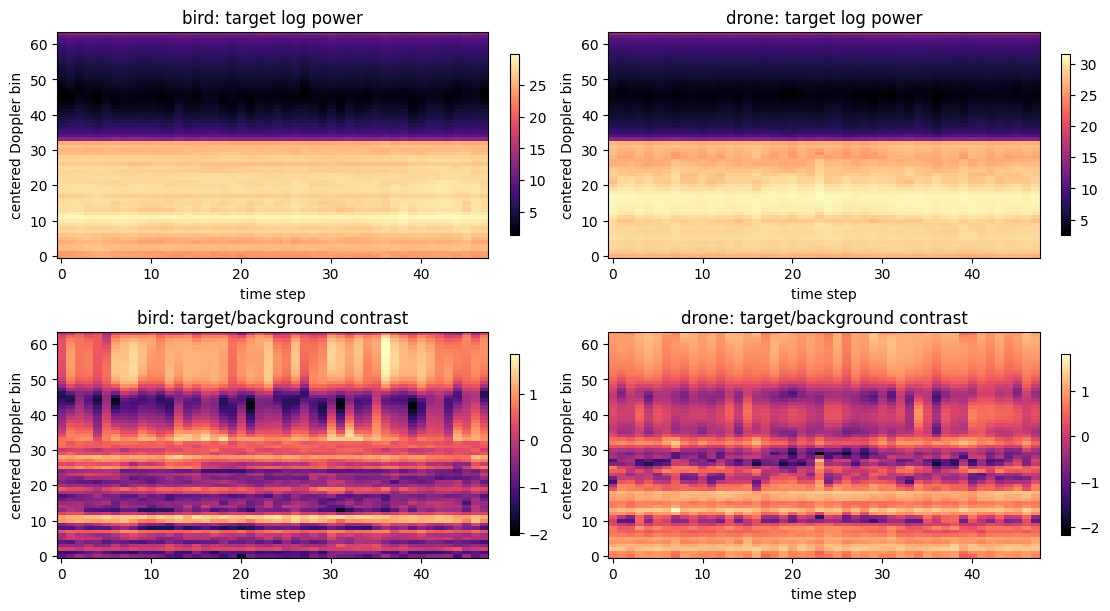

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)
for column, class_name in enumerate(["bird", "drone"]):
    example = X[np.flatnonzero(y_name == class_name)[0]]
    for channel in range(2):
        image = axes[channel, column].imshow(example[channel].T, origin="lower", aspect="auto", cmap="magma")
        axes[channel, column].set_title(f"{class_name}: {'target log power' if channel == 0 else 'target/background contrast'}")
        axes[channel, column].set_xlabel("time step")
        axes[channel, column].set_ylabel("centered Doppler bin")
        fig.colorbar(image, ax=axes[channel, column], shrink=0.8)
plt.show()


### Rotor-processed view of one archive recording

Set `ROTOR_VIEW_RECORDING`, `ROTOR_VIEW_FRAME_START`, and `ROTOR_VIEW_FRAME_COUNT` below to inspect any audited archive recording without rebuilding the feature cache or retraining. The selected range bin is the label-independent bin found earlier from the strongest accumulated non-zero-Doppler response over the complete recording.

This view calls the dedicated rotor DSP used by the live display: a three-bin range gate, 16-chirp Hann windows with a two-chirp hop and 128-point FFT, Hann-weighted complex-mean cancellation, a central $\pm2$-bin notch, robust per-window noise-floor subtraction and adaptive gating, and the 3×3 support filter. The lower panel is the same broadband flash score used by the rotor path.

**Axis limitation:** the archive does not contain trustworthy chirp timing or range calibration. Therefore this diagnostic uses centered Doppler-bin and STFT-window indices—not seconds, radial velocity, physical range, or RPM. It is separate from the classifier's `[2, 48, 64]` input visualization above.


The cell reports gate and retained-signal diagnostics and stops with an actionable error if processing would otherwise produce a silently empty plot.


In [ ]:
from types import SimpleNamespace

from rawdatacapture.dsp import (
    DEFAULT_ROTOR_NOISE_GATE_MAX_DB,
    compute_rotor_micro_doppler_frame,
)
from rawdatacapture.livedatacapture import (
    ROTOR_MICRO_DOPPLER_DC_NOTCH_BINS,
    ROTOR_MICRO_DOPPLER_FFT_SIZE,
    ROTOR_MICRO_DOPPLER_HOP_LOOPS,
    ROTOR_MICRO_DOPPLER_RANGE_HALF_WIDTH_BINS,
    ROTOR_MICRO_DOPPLER_RELATIVE_DB_MAX,
    ROTOR_MICRO_DOPPLER_WINDOW_LOOPS,
)

ROTOR_VIEW_RECORDING = "mavik_0_rotation"
ROTOR_VIEW_FRAME_START = 0
ROTOR_VIEW_FRAME_COUNT = 8

# Timing is required by the shared result type, but it does not affect the
# raw or enhanced spectral values. Generated physical axes are not plotted.
_ARCHIVE_ROTOR_CONFIG = SimpleNamespace(
    num_chirps_per_loop=1,
    idle_time_us=0.0,
    ramp_end_time_us=1.0,
    start_frequency_ghz=60.0,
)

def archive_frame_to_rotor_result(raw_frame: np.ndarray, selected_range_bin: int):
    frame = np.asarray(raw_frame)
    if frame.ndim != 2 or not np.iscomplexobj(frame) or not np.isfinite(frame).all():
        raise ValueError("Archive rotor input must be a finite complex [chirp, fast-time] frame")
    if frame.shape[0] < ROTOR_MICRO_DOPPLER_WINDOW_LOOPS:
        raise ValueError("Archive frame has too few chirps for the rotor STFT window")
    center_bin = int(selected_range_bin)
    if not 0 <= center_bin < frame.shape[1]:
        raise ValueError(f"Selected range bin {center_bin} is outside 0:{frame.shape[1]}")

    range_window = np.hanning(frame.shape[1]).astype(np.float32)
    range_fft = sp_fft.fft(frame * range_window, axis=-1, workers=1)[:, None, :]
    return compute_rotor_micro_doppler_frame(
        range_fft,
        np.arange(frame.shape[1], dtype=np.float32),
        _ARCHIVE_ROTOR_CONFIG,
        target_range_m=float(center_bin),  # bin units only; not metres
        frame_time_s=0.0,
        range_half_width_bins=ROTOR_MICRO_DOPPLER_RANGE_HALF_WIDTH_BINS,
        window_loops=ROTOR_MICRO_DOPPLER_WINDOW_LOOPS,
        hop_loops=ROTOR_MICRO_DOPPLER_HOP_LOOPS,
        fft_size=ROTOR_MICRO_DOPPLER_FFT_SIZE,
        dc_notch_bins=ROTOR_MICRO_DOPPLER_DC_NOTCH_BINS,
    )

rotor_rows = [row for row in metadata if row["recording_id"] == ROTOR_VIEW_RECORDING]
if len(rotor_rows) != 1:
    available = ", ".join(sorted(row["recording_id"] for row in metadata)[:12])
    raise ValueError(
        f"Expected one recording named {ROTOR_VIEW_RECORDING!r}; found {len(rotor_rows)}. "
        f"Example available IDs: {available}"
    )
rotor_row = rotor_rows[0]
rotor_feature_indices = np.flatnonzero(recording_ids == ROTOR_VIEW_RECORDING)
if rotor_feature_indices.size == 0:
    raise ValueError(f"No cached feature windows found for {ROTOR_VIEW_RECORDING!r}")
rotor_range_bins = np.unique(selected_range_bins[rotor_feature_indices])
if rotor_range_bins.size != 1:
    raise ValueError(f"Expected one selected range bin; found {rotor_range_bins.tolist()}")
rotor_range_bin = int(rotor_range_bins[0])

rotor_source, rotor_member = stage_recording_locally(
    DATA_SOURCE, rotor_row["name"], rotor_row["size"], rotor_row.get("drive_file_id")
)
rotor_raw = load_recording(rotor_source, rotor_member)
rotor_frame_start = int(ROTOR_VIEW_FRAME_START)
rotor_frame_count = int(ROTOR_VIEW_FRAME_COUNT)
rotor_frame_stop = rotor_frame_start + rotor_frame_count
if rotor_frame_start < 0 or rotor_frame_count <= 0 or rotor_frame_stop > len(rotor_raw):
    raise ValueError(
        f"Requested archive frames {rotor_frame_start}:{rotor_frame_stop}; "
        f"valid recording extent is 0:{len(rotor_raw)}"
    )

rotor_results = [
    archive_frame_to_rotor_result(rotor_raw[index], rotor_range_bin)
    for index in range(rotor_frame_start, rotor_frame_stop)
]
if any(result.enhanced_spectrogram_db.size == 0 for result in rotor_results):
    raise RuntimeError("Rotor processing returned an empty archive-frame spectrogram")
rotor_spectrogram_db = np.concatenate(
    [result.enhanced_spectrogram_db for result in rotor_results], axis=1
)
rotor_flash_scores_db = np.concatenate(
    [result.flash_scores_db for result in rotor_results]
)
rotor_noise_gate_db = np.concatenate(
    [result.noise_gate_db for result in rotor_results]
)
assert rotor_spectrogram_db.shape == (
    ROTOR_MICRO_DOPPLER_FFT_SIZE,
    rotor_flash_scores_db.size,
)
assert (
    np.isfinite(rotor_spectrogram_db).all()
    and np.isfinite(rotor_flash_scores_db).all()
    and np.isfinite(rotor_noise_gate_db).all()
)
rotor_retained = rotor_spectrogram_db > 0.0
rotor_diagnostics = {
    "recording": ROTOR_VIEW_RECORDING,
    "label": rotor_row["label"],
    "archive_frames": [rotor_frame_start, rotor_frame_stop],
    "selected_range_bin": rotor_range_bin,
    "rotor_spectrogram_shape": rotor_spectrogram_db.shape,
    "noise_gate_db_percentiles": np.percentile(
        rotor_noise_gate_db, [0, 50, 95, 100]
    ).round(3).tolist(),
    "maximum_gate_db": DEFAULT_ROTOR_NOISE_GATE_MAX_DB,
    "retained_cell_fraction": float(np.mean(rotor_retained)),
    "enhanced_peak_db": float(np.max(rotor_spectrogram_db)),
    "flash_peak_db": float(np.max(rotor_flash_scores_db)),
}
print(rotor_diagnostics)
if not np.any(rotor_retained):
    raise RuntimeError(
        "Rotor processing retained no signal cells. Restart the runtime so "
        "the updated bounded-gate DSP is imported, then rerun this cell."
    )

# The enhanced data retains numeric zeros at DC; the live display masks this
# region in gray. Apply that display-only mask without changing the result.
rotor_display_db = rotor_spectrogram_db.copy()
rotor_fft_center = rotor_display_db.shape[0] // 2
rotor_notch_start = rotor_fft_center - ROTOR_MICRO_DOPPLER_DC_NOTCH_BINS
rotor_notch_stop = rotor_fft_center + ROTOR_MICRO_DOPPLER_DC_NOTCH_BINS + 1
rotor_display_db[rotor_notch_start:rotor_notch_stop] = np.nan
rotor_window_count = rotor_display_db.shape[1]
rotor_window_centers = np.arange(rotor_window_count, dtype=np.float32) + 0.5

rotor_colormap = plt.get_cmap("turbo").copy()
rotor_colormap.set_bad(color="0.35")
fig, (rotor_axis, flash_axis) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": [4, 1]},
)
rotor_image = rotor_axis.imshow(
    rotor_display_db,
    origin="lower",
    aspect="auto",
    cmap=rotor_colormap,
    vmin=0.0,
    vmax=ROTOR_MICRO_DOPPLER_RELATIVE_DB_MAX,
    extent=(0, rotor_window_count, -ROTOR_MICRO_DOPPLER_FFT_SIZE // 2,
            ROTOR_MICRO_DOPPLER_FFT_SIZE // 2),
)
rotor_axis.set_title(
    f"Rotor-processed archive micro-Doppler — {ROTOR_VIEW_RECORDING} "
    f"({rotor_row['label']}; range bin {rotor_range_bin}; "
    f"frames {rotor_frame_start}:{rotor_frame_stop})"
)
rotor_axis.set_ylabel("Centered Doppler bin")
fig.colorbar(rotor_image, ax=rotor_axis, label="Power above robust noise floor (dB)")

flash_axis.plot(rotor_window_centers, rotor_flash_scores_db, color="tab:blue", linewidth=1.0)
flash_axis.set(xlabel="Rotor STFT window index (archive timing unavailable)",
               ylabel="Flash score (dB)", xlim=(0, rotor_window_count),
               ylim=(0, ROTOR_MICRO_DOPPLER_RELATIVE_DB_MAX))
flash_axis.grid(True, alpha=0.25)
plt.show()

del rotor_raw, rotor_results
release_recording_memory()


## 4. Grouped split, train-only normalization, and model selection

Unknown examples are excluded from the binary loss. `StratifiedGroupKFold` creates train, validation, and locked test partitions with disjoint inferred session groups. Clipping limits and channel-wise mean/standard deviation are fitted on training pixels only.

The model is L2-regularized logistic regression. This intentionally implements the simple baseline required before accepting a deeper CNN in `AI_2.md`, uses the repository's existing scikit-learn dependency, and is small enough for non-blocking CPU inference. `C` and the decision threshold are chosen on validation data only. A one-dimensional sigmoid calibrator is also fitted on validation logits; the locked test set is touched once.

In [8]:
binary = y_name != "unknown"
binary_indices = np.flatnonzero(binary)
y = (y_name[binary] == "drone").astype(np.int8)
groups = session_groups[binary]

outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
trainval_rel, test_rel = next(outer.split(np.zeros(len(y)), y, groups))
inner = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE + 1)
train_rel2, val_rel2 = next(inner.split(np.zeros(len(trainval_rel)), y[trainval_rel], groups[trainval_rel]))
train_rel, val_rel = trainval_rel[train_rel2], trainval_rel[val_rel2]
train_idx, val_idx, test_idx = binary_indices[train_rel], binary_indices[val_rel], binary_indices[test_rel]

split_indices = {"train": train_idx, "validation": val_idx, "test": test_idx}
for split, idx in split_indices.items():
    print(split, {"windows": len(idx), "recordings": len(np.unique(recording_ids[idx])),
                  "groups": len(np.unique(session_groups[idx])), "classes": dict(Counter(y_name[idx]))})
group_sets = {name: set(session_groups[idx]) for name, idx in split_indices.items()}
recording_sets = {name: set(recording_ids[idx]) for name, idx in split_indices.items()}
for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    assert group_sets[a].isdisjoint(group_sets[b])
    assert recording_sets[a].isdisjoint(recording_sets[b])

clip_low = np.percentile(X[train_idx], 0.5, axis=(0, 2, 3)).astype(np.float32)
clip_high = np.percentile(X[train_idx], 99.5, axis=(0, 2, 3)).astype(np.float32)
def clipped(X_part):
    return np.clip(X_part, clip_low[None, :, None, None], clip_high[None, :, None, None])
train_clipped = clipped(X[train_idx])
channel_mean = train_clipped.mean(axis=(0, 2, 3), dtype=np.float64).astype(np.float32)
channel_std = train_clipped.std(axis=(0, 2, 3), dtype=np.float64).astype(np.float32)
assert np.all(channel_std > 0)

def transform(X_part: np.ndarray) -> np.ndarray:
    normalized = (clipped(X_part) - channel_mean[None, :, None, None]) / channel_std[None, :, None, None]
    return normalized.reshape(len(normalized), -1).astype(np.float32, copy=False)

X_train, X_val = transform(X[train_idx]), transform(X[val_idx])
y_train = (y_name[train_idx] == "drone").astype(np.int8)
y_val = (y_name[val_idx] == "drone").astype(np.int8)
candidates = []
for C in [0.01, 0.1, 1.0]:
    candidate = LogisticRegression(C=C, solver="liblinear", penalty="l2", class_weight="balanced",
                                   max_iter=500, random_state=RANDOM_STATE)
    candidate.fit(X_train, y_train)
    val_score = average_precision_score(y_val, candidate.predict_proba(X_val)[:, 1])
    candidates.append((val_score, C, candidate))
    print(f"C={C:g}: validation PR-AUC={val_score:.4f}, iterations={candidate.n_iter_[0]}")
_, selected_C, model = max(candidates, key=lambda row: row[0])

val_logits = model.decision_function(X_val).reshape(-1, 1)
calibrator = LogisticRegression(C=1e3, solver="lbfgs", max_iter=500, random_state=RANDOM_STATE)
calibrator.fit(val_logits, y_val)
val_probability = calibrator.predict_proba(val_logits)[:, 1]
precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, val_probability)
f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / np.maximum(precision_curve[:-1] + recall_curve[:-1], 1e-12)
threshold = float(thresholds[np.argmax(f1_curve)])
print(f"selected C={selected_C:g}; validation F1 threshold={threshold:.4f}")


train {'windows': 2520, 'recordings': 63, 'groups': 32, 'classes': {np.str_('bird'): 960, np.str_('drone'): 1560}}
validation {'windows': 762, 'recordings': 18, 'groups': 10, 'classes': {np.str_('bird'): 320, np.str_('drone'): 442}}
test {'windows': 800, 'recordings': 20, 'groups': 10, 'classes': {np.str_('bird'): 240, np.str_('drone'): 560}}
C=0.01: validation PR-AUC=0.8231, iterations=8
C=0.1: validation PR-AUC=0.7845, iterations=9
C=1: validation PR-AUC=0.7570, iterations=10
selected C=0.01; validation F1 threshold=0.3911


## 5. Locked-test evaluation

Metrics are reported per window and after averaging probabilities across each complete recording. Bird false-positive rate is `FP / (FP + TN)`. Expected calibration error (ECE) uses ten fixed probability bins. These archive results do not estimate operational false alarms per hour.

Window metrics:
 {
  "samples": 800,
  "threshold": 0.3910918631667686,
  "drone_recall": 0.9589285714285715,
  "bird_false_positive_rate": 0.5333333333333333,
  "precision": 0.8075187969924812,
  "f1": 0.876734693877551,
  "pr_auc_average_precision": 0.8642669952557194,
  "roc_auc": 0.7645982142857143,
  "brier_score": 0.15773520982949332,
  "ece_10_bins": 0.1344415075278919,
  "confusion_matrix_tn_fp_fn_tp": [
    112,
    128,
    23,
    537
  ]
}
Recording metrics:
 {
  "samples": 20,
  "threshold": 0.3910918631667686,
  "drone_recall": 1.0,
  "bird_false_positive_rate": 0.6666666666666666,
  "precision": 0.7777777777777778,
  "f1": 0.875,
  "pr_auc_average_precision": 0.8758539079967651,
  "roc_auc": 0.7857142857142858,
  "brier_score": 0.1574347157150966,
  "ece_10_bins": 0.23948604775635346,
  "confusion_matrix_tn_fp_fn_tp": [
    2,
    4,
    0,
    14
  ]
}


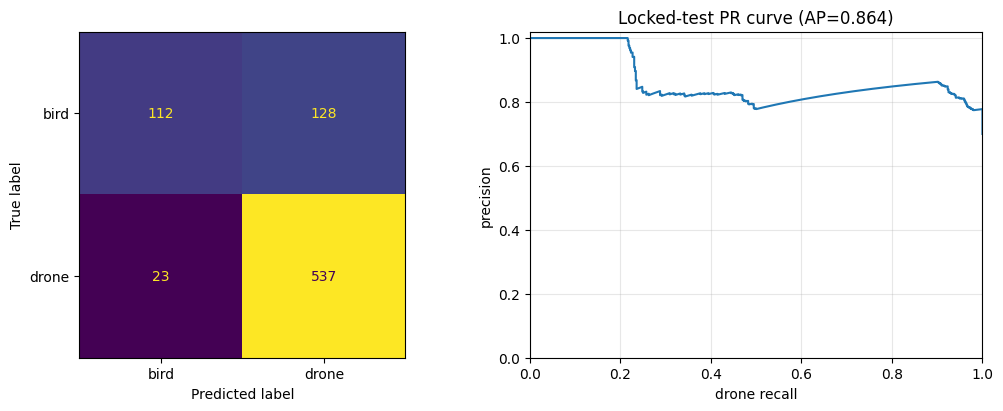

Unknown pole probe (not a general negative metric): {'windows': 40, 'mean_p_drone': 0.16033890262527098, 'max_p_drone': 0.17070483013952253, 'fraction_above_threshold': 0.0}


In [9]:
def calibrated_probability(X_flat: np.ndarray) -> np.ndarray:
    return calibrator.predict_proba(model.decision_function(X_flat).reshape(-1, 1))[:, 1]

def expected_calibration_error(y_true, probability, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    bucket = np.minimum(np.digitize(probability, edges[1:-1]), bins - 1)
    ece = 0.0
    for index in range(bins):
        mask = bucket == index
        if mask.any():
            ece += mask.mean() * abs(y_true[mask].mean() - probability[mask].mean())
    return float(ece)

def metric_summary(y_true, probability, selected_threshold):
    predicted = (probability >= selected_threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {
        "samples": int(len(y_true)), "threshold": float(selected_threshold),
        "drone_recall": float(recall_score(y_true, predicted)),
        "bird_false_positive_rate": float(fp / max(fp + tn, 1)),
        "precision": float(precision_score(y_true, predicted, zero_division=0)),
        "f1": float(f1_score(y_true, predicted)),
        "pr_auc_average_precision": float(average_precision_score(y_true, probability)),
        "roc_auc": float(roc_auc_score(y_true, probability)),
        "brier_score": float(brier_score_loss(y_true, probability)),
        "ece_10_bins": expected_calibration_error(y_true, probability),
        "confusion_matrix_tn_fp_fn_tp": [int(tn), int(fp), int(fn), int(tp)],
    }

X_test = transform(X[test_idx])
y_test = (y_name[test_idx] == "drone").astype(np.int8)
test_probability = calibrated_probability(X_test)
window_metrics = metric_summary(y_test, test_probability, threshold)
print("Window metrics:\n", json.dumps(window_metrics, indent=2))

record_rows = []
for recording in np.unique(recording_ids[test_idx]):
    mask = recording_ids[test_idx] == recording
    record_rows.append((recording, int(y_test[mask][0]), float(test_probability[mask].mean()), int(mask.sum())))
record_y = np.array([row[1] for row in record_rows], dtype=np.int8)
record_probability = np.array([row[2] for row in record_rows], dtype=np.float64)
record_metrics = metric_summary(record_y, record_probability, threshold)
print("Recording metrics:\n", json.dumps(record_metrics, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(y_test, test_probability >= threshold, display_labels=["bird", "drone"], ax=axes[0], colorbar=False)
p, r, _ = precision_recall_curve(y_test, test_probability)
axes[1].plot(r, p)
axes[1].set(xlabel="drone recall", ylabel="precision", title=f"Locked-test PR curve (AP={window_metrics['pr_auc_average_precision']:.3f})", xlim=(0, 1), ylim=(0, 1.02))
axes[1].grid(alpha=0.3)
plt.show()

unknown_idx = np.flatnonzero(y_name == "unknown")
unknown_summary = None
if len(unknown_idx):
    unknown_probability = calibrated_probability(transform(X[unknown_idx]))
    unknown_summary = {"windows": len(unknown_idx), "mean_p_drone": float(unknown_probability.mean()),
                       "max_p_drone": float(unknown_probability.max()),
                       "fraction_above_threshold": float((unknown_probability >= threshold).mean())}
    print("Unknown pole probe (not a general negative metric):", unknown_summary)


## 6. Current live-pipeline compatibility check

The adapter below consumes the repository's real live radar cube layout `[384 chirps, 4 RX, 64 ADC samples]`, calls the same range/Doppler functions as `livedatacapture.py`, applies the same five-bin target gate, computes a separated background, and returns one `[2, 64]` step. A caller maintains 48 valid steps and must reset/mark unknown after track loss, frame gaps, processing drops, or a profile fingerprint mismatch. Inference belongs after feature generation in the processing process or in another bounded worker; it must never block UDP reception.

Passing the shape test proves software compatibility only. It does **not** prove domain transfer from the archive's different 60 GHz acquisition system.

In [10]:
def live_cube_to_feature_step(radar_cube: np.ndarray, target_range_bin: int, config=profile) -> np.ndarray:
    expected = (config.num_chirps_per_frame, config.num_rx_channels, config.num_adc_samples)
    if radar_cube.shape != expected or not np.iscomplexobj(radar_cube) or not np.isfinite(radar_cube).all():
        raise ValueError(f"Expected finite complex live cube {expected}; received {radar_cube.shape}")
    target_bins, background_bins = _range_indices(int(target_range_bin), config.num_adc_samples)
    try:
        doppler_cube = compute_range_doppler_fft(compute_range_fft(radar_cube), config)
    except RuntimeError as exc:
        # The User guide pins OpenRadar. This fallback keeps the
        # notebook testable when that optional runtime is absent, while matching
        # its Hann windows, TDM layout, FFT axes, and centered Doppler order.
        warnings.warn(f"Repository OpenRadar backend unavailable; using equivalent SciPy FFT fallback. {exc}")
        range_window = np.hanning(config.num_adc_samples).astype(np.float32)
        range_fft = sp_fft.fft(radar_cube * range_window, axis=-1, workers=1)
        explicit = range_fft.reshape(config.num_loops, config.num_chirps_per_loop,
                                     config.num_rx_channels, config.num_adc_samples)
        doppler_window = np.hanning(config.num_loops).astype(np.float32)[:, None, None, None]
        doppler_cube = sp_fft.fftshift(sp_fft.fft(explicit * doppler_window, axis=0, workers=1), axes=0)
    target_power = (np.abs(doppler_cube[..., target_bins]) ** 2).mean(axis=(1, 2, 3))
    background_power = (np.abs(doppler_cube[..., background_bins]) ** 2).mean(axis=(1, 2, 3))
    target_power = reduce_centered_doppler(target_power)
    background_power = reduce_centered_doppler(background_power)
    log_target = np.log1p(target_power)
    return np.stack([log_target, log_target - np.log1p(background_power)]).astype(np.float32)

def predict_feature_window(window: np.ndarray, observed_profile_sha256: str) -> dict:
    if observed_profile_sha256 != profile_sha256:
        return {"label": "unknown", "reason": "radar_configuration_mismatch"}
    if window.shape != (2, WINDOW_STEPS, DOPPLER_BINS) or not np.isfinite(window).all():
        return {"label": "unknown", "reason": "invalid_or_incomplete_feature_window"}
    probability = float(calibrated_probability(transform(window[None]))[0])
    return {"label": "drone" if probability >= threshold else "bird", "p_drone": probability,
            "threshold": threshold, "status": "archive_pretrained_unvalidated_on_iwr6843"}

dummy_cube = np.zeros((profile.num_chirps_per_frame, profile.num_rx_channels, profile.num_adc_samples), dtype=np.complex64)
dummy_step = live_cube_to_feature_step(dummy_cube, target_range_bin=16)
assert dummy_step.shape == (2, 64) and np.isfinite(dummy_step).all()
assert predict_feature_window(np.zeros((2, 48, 64), dtype=np.float32), "wrong")["label"] == "unknown"
print("Live adapter shape test passed:", dummy_step.shape)


Live adapter shape test passed: (2, 64)


/tmp/ipykernel_971/2887880932.py:12: UserWarning: Repository OpenRadar backend unavailable; using equivalent SciPy FFT fallback. OpenRadar DSP is required. Create the project virtual environment as described in 'rawdatacapture/User guide.md', install the capture dependencies listed there, and run the application with that environment's Python. Import error: No module named 'mmwave'
  warnings.warn(f"Repository OpenRadar backend unavailable; using equivalent SciPy FFT fallback. {exc}")


## 7. Export

The bundle contains the fitted classifier, probability calibrator, validation threshold, train-only preprocessing parameters, feature schema, fingerprints, and explicit deployment status. It is a candidate for replay experiments—not permission to enable operational live decisions.

In [11]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
model_path = ARTIFACT_DIR / "drone_bird_archive_logistic.joblib"
model_card_path = ARTIFACT_DIR / "drone_bird_archive_logistic.model_card.json"
bundle = {
    "model": model, "calibrator": calibrator, "threshold": threshold,
    "clip_low": clip_low, "clip_high": clip_high,
    "channel_mean": channel_mean, "channel_std": channel_std,
    "selected_C": selected_C, "feature_version": FEATURE_VERSION,
    "input_shape_chw": (2, 48, 64),
    "archive_manifest_sha256": archive_fingerprint,
    "compatible_profile_sha256": profile_sha256,
    "deployment_status": "archive_pretrained_unvalidated_on_iwr6843",
}
joblib.dump(bundle, model_path, compress=3)
model_card = {
    "artifact": model_path.name, "created_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "objective": "drone versus bionic bird micro-Doppler archive baseline",
    "deployment_status": bundle["deployment_status"],
    "dataset": {"data_source_at_training": str(DATA_SOURCE), "source_kind": source_kind,
                "manifest_sha256": archive_fingerprint,
                "recording_counts": dict(Counter(row["target_model"] for row in metadata)),
                "session_group_source": "inferred from filenames; authoritative session metadata unavailable"},
    "feature_contract": {"version": FEATURE_VERSION, "shape": [2, 48, 64],
        "axis_order": ["channel", "time", "centered_doppler"],
        "channels": ["target_gate_log1p_power", "target_minus_local_background_log1p_power"],
        "target_gate_range_bins": 5, "normalization": "training-only channel clipping and standardization"},
    "active_radar_contract": active_contract, "selected_C": selected_C, "threshold": threshold,
    "window_test_metrics": window_metrics, "recording_test_metrics": record_metrics,
    "unknown_pole_probe": unknown_summary,
    "limitations": [
        "No held-out IWR6843ISK-ODS labelled data were available.",
        "The negative class is bionic bird; it does not cover general non-drone clutter.",
        "Archive frame timing and authoritative session IDs are unavailable.",
        "The archive and live radar use different acquisition systems; live transfer is unvalidated.",
        "One pole recording is only an unknown probe and cannot estimate false alarms per hour.",
    ],
    "software": {"python": platform.python_version(), "numpy": np.__version__,
                 "scipy": scipy.__version__, "scikit_learn": sklearn_version},
}
model_card_path.write_text(json.dumps(model_card, indent=2), encoding="utf-8")
print("Saved:", model_path, model_path.stat().st_size, "bytes")
print("Saved:", model_card_path)


Saved: /content/drive/MyDrive/UREX/Radar-UREx-output/artifacts/drone_bird_archive_logistic.joblib 48646 bytes
Saved: /content/drive/MyDrive/UREX/Radar-UREx-output/artifacts/drone_bird_archive_logistic.model_card.json


## 8. Compact depthwise-separable 2D CNN (implemented, not trained)

The following cells implement the Phase 1 CNN proposed in `AI_2.md`. They are intentionally left **unexecuted**: the current kernel does not have PyTorch installed, and training was not requested for this revision. Follow the optional CNN installation section in `rawdatacapture/User guide.md` and use a dedicated, [PyTorch-supported Python environment](https://pytorch.org/get-started/locally/) before running them.

The network consumes the same normalized `[batch, 2, 48, 64]` feature contract as the logistic baseline. Three residual depthwise-separable blocks learn local time/Doppler patterns, while global average pooling avoids a large fully connected layer. The parameter-count assertion keeps the model below the one-million-parameter Phase 1 limit.

In [12]:
# Dependency check only; this cell does not train anything.
try:
    import copy
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, Dataset
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    TORCH_AVAILABLE = False
    print("PyTorch is not installed. Follow the optional CNN installation steps in rawdatacapture/User guide.md.")


In [13]:
CNN_CONFIG = {
    "input_channels": 2,
    "stem_channels": 16,
    "block_channels": [32, 64, 96],
    "block_strides": [(1, 2), (2, 2), (2, 2)],
    "dropout": 0.25,
}

if TORCH_AVAILABLE:
    class DepthwiseSeparableResidual(nn.Module):
        """Residual depthwise 3x3 convolution followed by pointwise 1x1 mixing."""

        def __init__(self, in_channels: int, out_channels: int, stride=(1, 1)):
            super().__init__()
            self.main = nn.Sequential(
                nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride,
                          padding=1, groups=in_channels, bias=False),
                nn.BatchNorm2d(in_channels),
                nn.SiLU(inplace=True),
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
            self.skip = (
                nn.Identity()
                if in_channels == out_channels and tuple(stride) == (1, 1)
                else nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                    nn.BatchNorm2d(out_channels),
                )
            )
            self.activation = nn.SiLU(inplace=True)

        def forward(self, inputs):
            return self.activation(self.main(inputs) + self.skip(inputs))

    class MicroDopplerCNN(nn.Module):
        """Compact binary classifier returning one uncalibrated drone logit."""

        def __init__(self, config=CNN_CONFIG):
            super().__init__()
            stem = int(config["stem_channels"])
            channels = [stem, *map(int, config["block_channels"])]
            self.stem = nn.Sequential(
                nn.Conv2d(int(config["input_channels"]), stem, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(stem),
                nn.SiLU(inplace=True),
            )
            self.blocks = nn.Sequential(*[
                DepthwiseSeparableResidual(channels[i], channels[i + 1], tuple(config["block_strides"][i]))
                for i in range(len(config["block_channels"]))
            ])
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.dropout = nn.Dropout(float(config["dropout"]))
            self.classifier = nn.Linear(channels[-1], 1)

        def forward(self, inputs):
            if inputs.ndim != 4 or tuple(inputs.shape[1:]) != (2, 48, 64):
                raise ValueError(f"Expected [batch, 2, 48, 64], received {tuple(inputs.shape)}")
            features = self.blocks(self.stem(inputs))
            return self.classifier(self.dropout(self.pool(features).flatten(1))).squeeze(1)

    cnn = MicroDopplerCNN()
    cnn_parameter_count = sum(parameter.numel() for parameter in cnn.parameters() if parameter.requires_grad)
    with torch.no_grad():
        shape_check = cnn(torch.zeros(2, 2, 48, 64, dtype=torch.float32))
    assert shape_check.shape == (2,)
    assert cnn_parameter_count < 1_000_000
    print(f"CNN trainable parameters: {cnn_parameter_count:,}")
else:
    print("CNN definition skipped because PyTorch is unavailable. No training was run.")


CNN trainable parameters: 19,825


### CNN input pipeline and radar-safe augmentation

The CNN reuses the exact grouped indices and **training-only** clipping/normalization parameters established above. Augmentation is limited to small standardized-amplitude/noise changes, zero-padded time and Doppler shifts, and masked-frame dropout. It deliberately excludes rotations, flips, warping, and circular shifts that would invent physically misleading radar structure. Validation and test windows are never augmented.

In [14]:
if TORCH_AVAILABLE:
    def transform_cnn(X_part: np.ndarray) -> np.ndarray:
        normalized = (clipped(X_part) - channel_mean[None, :, None, None]) / channel_std[None, :, None, None]
        result = normalized.astype(np.float32, copy=False)
        if result.ndim != 4 or result.shape[1:] != (2, 48, 64) or not np.isfinite(result).all():
            raise ValueError(f"Invalid CNN tensor: {result.shape}")
        return result

    def zero_padded_shift(tensor, amount: int, dimension: int):
        if amount == 0:
            return tensor
        shifted = torch.zeros_like(tensor)
        source = [slice(None)] * tensor.ndim
        destination = [slice(None)] * tensor.ndim
        if amount > 0:
            source[dimension] = slice(None, -amount)
            destination[dimension] = slice(amount, None)
        else:
            source[dimension] = slice(-amount, None)
            destination[dimension] = slice(None, amount)
        shifted[tuple(destination)] = tensor[tuple(source)]
        return shifted

    class RadarWindowDataset(Dataset):
        def __init__(self, windows: np.ndarray, labels: np.ndarray, augment: bool = False):
            if windows.shape[1:] != (2, 48, 64) or len(windows) != len(labels):
                raise ValueError("CNN dataset expects matching [N, 2, 48, 64] windows and labels")
            self.windows = windows
            self.labels = labels.astype(np.float32, copy=False)
            self.augment = augment

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, index):
            window = torch.from_numpy(self.windows[index].copy())
            if self.augment:
                # Small log-power perturbation; contrast is left physically relative.
                window[0] += torch.empty(1).uniform_(-0.08, 0.08).item()
                window += torch.randn_like(window) * 0.01
                window = zero_padded_shift(window, int(torch.randint(-2, 3, ()).item()), dimension=1)
                window = zero_padded_shift(window, int(torch.randint(-2, 3, ()).item()), dimension=2)
                if torch.rand(()) < 0.25:
                    dropped = torch.rand(window.shape[1]) < 0.05
                    window[:, dropped, :] = 0.0  # zero is padding after standardization
            return window, torch.tensor(self.labels[index], dtype=torch.float32)

    cnn_train_windows = transform_cnn(X[train_idx])
    cnn_val_windows = transform_cnn(X[val_idx])
    cnn_test_windows = transform_cnn(X[test_idx])
    cnn_train_labels = (y_name[train_idx] == "drone").astype(np.float32)
    cnn_val_labels = (y_name[val_idx] == "drone").astype(np.float32)
    cnn_test_labels = (y_name[test_idx] == "drone").astype(np.float32)
    print("CNN datasets prepared; training has not been run.",
          cnn_train_windows.shape, cnn_val_windows.shape, cnn_test_windows.shape)


CNN datasets prepared; training has not been run. (2520, 2, 48, 64) (762, 2, 48, 64) (800, 2, 48, 64)


### Training loop — run manually when ready

This cell trains with weighted binary cross-entropy, AdamW, gradient clipping, and validation PR-AUC early stopping. It restores the best validation checkpoint before any test-set evaluation. It does not combine train and validation after selection, because the validation logits are subsequently used for probability calibration and threshold selection.

In [15]:
# INTENTIONALLY NOT EXECUTED IN THIS REVISION. Run this cell to train the CNN.
if not TORCH_AVAILABLE:
    raise RuntimeError("PyTorch is required. Follow the optional CNN installation steps in rawdatacapture/User guide.md.")

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loader_generator = torch.Generator().manual_seed(RANDOM_STATE)
train_loader = DataLoader(RadarWindowDataset(cnn_train_windows, cnn_train_labels, augment=True),
                          batch_size=32, shuffle=True, num_workers=0, generator=loader_generator)
val_loader = DataLoader(RadarWindowDataset(cnn_val_windows, cnn_val_labels),
                        batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(RadarWindowDataset(cnn_test_windows, cnn_test_labels),
                         batch_size=64, shuffle=False, num_workers=0)

cnn = MicroDopplerCNN().to(device)
negative_count = float((cnn_train_labels == 0).sum())
positive_count = float((cnn_train_labels == 1).sum())
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([negative_count / positive_count], device=device))
optimizer = torch.optim.AdamW(cnn.parameters(), lr=1e-3, weight_decay=1e-4)

def cnn_logits(data_loader):
    cnn.eval()
    logits, labels = [], []
    with torch.inference_mode():
        for windows, targets in data_loader:
            logits.append(cnn(windows.to(device)).cpu().numpy())
            labels.append(targets.numpy())
    return np.concatenate(logits), np.concatenate(labels).astype(np.int8)

best_state, best_val_pr_auc, epochs_without_improvement = None, -np.inf, 0
cnn_history = []
for epoch in range(1, 101):
    cnn.train()
    running_loss = 0.0
    for windows, targets in train_loader:
        windows, targets = windows.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(cnn(windows), targets)
        loss.backward()
        nn.utils.clip_grad_norm_(cnn.parameters(), max_norm=5.0)
        optimizer.step()
        running_loss += float(loss.detach()) * len(targets)
    val_logits_cnn, val_y_cnn = cnn_logits(val_loader)
    val_pr_auc = average_precision_score(val_y_cnn, val_logits_cnn)
    epoch_loss = running_loss / len(cnn_train_labels)
    cnn_history.append({"epoch": epoch, "train_loss": epoch_loss, "val_pr_auc": val_pr_auc})
    if val_pr_auc > best_val_pr_auc + 1e-4:
        best_val_pr_auc = val_pr_auc
        best_state = copy.deepcopy(cnn.state_dict())
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    print(f"epoch={epoch:03d} loss={epoch_loss:.4f} val_PR-AUC={val_pr_auc:.4f}")
    if epochs_without_improvement >= 12:
        print(f"Early stopping; restoring epoch {best_epoch}.")
        break
assert best_state is not None
cnn.load_state_dict(best_state)
cnn.eval()


epoch=001 loss=0.3093 val_PR-AUC=1.0000
epoch=002 loss=0.1011 val_PR-AUC=1.0000
epoch=003 loss=0.0478 val_PR-AUC=1.0000
epoch=004 loss=0.0235 val_PR-AUC=1.0000
epoch=005 loss=0.0156 val_PR-AUC=1.0000
epoch=006 loss=0.0098 val_PR-AUC=1.0000
epoch=007 loss=0.0059 val_PR-AUC=1.0000
epoch=008 loss=0.0061 val_PR-AUC=1.0000
epoch=009 loss=0.0049 val_PR-AUC=0.9998
epoch=010 loss=0.0028 val_PR-AUC=1.0000
epoch=011 loss=0.0017 val_PR-AUC=1.0000
epoch=012 loss=0.0054 val_PR-AUC=1.0000
epoch=013 loss=0.0042 val_PR-AUC=1.0000
Early stopping; restoring epoch 1.


MicroDopplerCNN(
  (stem): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): DepthwiseSeparableResidual(
      (main): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 2), padding=(1, 1), groups=16, bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
        (3): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Sequential(
        (0): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (activation): SiLU(inplace=True)
    )
    (1): Depthwis

### CNN calibration, locked-test evaluation, and export

Run this only after the training cell. A sigmoid calibrator and F1 threshold are fitted from validation logits; the locked test remains untouched until final evaluation. The export separates the architecture/state dictionary from scikit-learn calibration data and records that IWR6843 transfer remains unvalidated.

In [16]:
# INTENTIONALLY NOT EXECUTED IN THIS REVISION. Requires a trained `cnn`.
val_logits_cnn, val_y_cnn = cnn_logits(val_loader)
cnn_calibrator = LogisticRegression(C=1e3, solver="lbfgs", max_iter=500, random_state=RANDOM_STATE)
cnn_calibrator.fit(val_logits_cnn.reshape(-1, 1), val_y_cnn)
cnn_val_probability = cnn_calibrator.predict_proba(val_logits_cnn.reshape(-1, 1))[:, 1]
cnn_precision, cnn_recall, cnn_thresholds = precision_recall_curve(val_y_cnn, cnn_val_probability)
cnn_f1 = 2 * cnn_precision[:-1] * cnn_recall[:-1] / np.maximum(cnn_precision[:-1] + cnn_recall[:-1], 1e-12)
cnn_threshold = float(cnn_thresholds[np.argmax(cnn_f1)])

test_logits_cnn, test_y_cnn = cnn_logits(test_loader)
cnn_test_probability = cnn_calibrator.predict_proba(test_logits_cnn.reshape(-1, 1))[:, 1]
cnn_window_metrics = metric_summary(test_y_cnn, cnn_test_probability, cnn_threshold)
print("CNN locked-test window metrics:\n", json.dumps(cnn_window_metrics, indent=2))
print("Logistic baseline window metrics:\n", json.dumps(window_metrics, indent=2))

cnn_record_rows = []
for recording in np.unique(recording_ids[test_idx]):
    mask = recording_ids[test_idx] == recording
    cnn_record_rows.append((recording, int(test_y_cnn[mask][0]), float(cnn_test_probability[mask].mean())))
cnn_record_y = np.array([row[1] for row in cnn_record_rows], dtype=np.int8)
cnn_record_probability = np.array([row[2] for row in cnn_record_rows], dtype=np.float64)
cnn_record_metrics = metric_summary(cnn_record_y, cnn_record_probability, cnn_threshold)

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
cnn_state_path = ARTIFACT_DIR / "drone_bird_cnn_state.pt"
cnn_calibration_path = ARTIFACT_DIR / "drone_bird_cnn_calibration.joblib"
cnn_card_path = ARTIFACT_DIR / "drone_bird_cnn.model_card.json"
torch.save({"state_dict": {k: v.detach().cpu() for k, v in cnn.state_dict().items()},
            "architecture": "MicroDopplerCNN", "cnn_config": CNN_CONFIG,
            "input_shape_chw": (2, 48, 64), "feature_version": FEATURE_VERSION}, cnn_state_path)
joblib.dump({"calibrator": cnn_calibrator, "threshold": cnn_threshold,
             "clip_low": clip_low, "clip_high": clip_high,
             "channel_mean": channel_mean, "channel_std": channel_std,
             "archive_manifest_sha256": archive_fingerprint,
             "compatible_profile_sha256": profile_sha256}, cnn_calibration_path, compress=3)
cnn_card = {"architecture": "compact depthwise-separable residual 2D CNN",
            "parameters": cnn_parameter_count, "best_epoch": best_epoch,
            "validation_pr_auc": best_val_pr_auc, "threshold": cnn_threshold,
            "window_test_metrics": cnn_window_metrics, "recording_test_metrics": cnn_record_metrics,
            "feature_version": FEATURE_VERSION, "input_shape_chw": [2, 48, 64],
            "archive_manifest_sha256": archive_fingerprint,
            "compatible_profile_sha256": profile_sha256,
            "deployment_status": "archive_pretrained_unvalidated_on_iwr6843"}
cnn_card_path.write_text(json.dumps(cnn_card, indent=2), encoding="utf-8")
print("Saved CNN artifacts:", cnn_state_path, cnn_calibration_path, cnn_card_path)


CNN locked-test window metrics:
 {
  "samples": 800,
  "threshold": 0.9829048509751203,
  "drone_recall": 0.9142857142857143,
  "bird_false_positive_rate": 0.3333333333333333,
  "precision": 0.8648648648648649,
  "f1": 0.8888888888888888,
  "pr_auc_average_precision": 0.9059661488152783,
  "roc_auc": 0.8471502976190477,
  "brier_score": 0.10331770281824643,
  "ece_10_bins": 0.11015325674463075,
  "confusion_matrix_tn_fp_fn_tp": [
    160,
    80,
    48,
    512
  ]
}
Logistic baseline window metrics:
 {
  "samples": 800,
  "threshold": 0.3910918631667686,
  "drone_recall": 0.9589285714285715,
  "bird_false_positive_rate": 0.5333333333333333,
  "precision": 0.8075187969924812,
  "f1": 0.876734693877551,
  "pr_auc_average_precision": 0.8642669952557194,
  "roc_auc": 0.7645982142857143,
  "brier_score": 0.15773520982949332,
  "ece_10_bins": 0.1344415075278919,
  "confusion_matrix_tn_fp_fn_tp": [
    112,
    128,
    23,
    537
  ]
}
Saved CNN artifacts: /content/drive/MyDrive/UREX/Rada

## Recommended next validation

1. Record labelled IWR6843 drone and real-bird sessions with persistent track IDs, frame-validity/drop masks, the profile fingerprint, range/aspect/motion metadata, and long drone-free background sessions.
2. Recreate these exact `[2, 48, 64]` features through the live adapter and compare archive-only, IWR-only, and archive-pretrained/IWR-fine-tuned results using locked session groups.
3. Add an explicit `time_mask` for early/incomplete tracks, probability smoothing per stable track, and an `unknown` state for gaps, track loss, poor quality, and configuration mismatch.
4. Train the implemented compact CNN, compare it with the existing logistic baseline on the identical locked split, then export the selected candidate to ONNX, verify numerical parity, and measure inference plus end-to-end latency without blocking the UDP receiver.
5. Do not report general non-drone performance or false alarms per hour until diverse real negative sessions exist.